# Portfolio Project Part 4: Cohort Analysis & Customer Retention Rates
This notebook tracks customer purchasing retention over time by grouping customers into monthly acquisition cohorts and visualizing their behavior using a retention matrix heatmap.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Drive and load datasets
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/e_commerce_database/'

orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
customers = pd.read_csv(os.path.join(base_path, 'customers.csv'))

# Merge orders with customer info
df = orders.merge(customers, on='CustomerID', how='inner')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

print("Data loaded successfully.")

Mounted at /content/drive
Data loaded successfully.


In [2]:
# 1. Extract Order Month and Assign Cohort Month (First Purchase Date)
def get_month(x):
    return pd.Timestamp(x.year, x.month, 1)

df['OrderMonth'] = df['OrderDate'].apply(get_month)
df['CohortMonth'] = df.groupby('CustomerID')['OrderMonth'].transform('min')

# 2. Calculate Cohort Index (Months elapsed since first purchase)
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

order_year, order_month = get_date_int(df, 'OrderMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

years_diff = order_year - cohort_year
months_diff = order_month - cohort_month

df['CohortIndex'] = years_diff * 12 + months_diff + 1

df[['CustomerID', 'CohortMonth', 'OrderMonth', 'CohortIndex']].head()

,CustomerID,CohortMonth,OrderMonth,CohortIndex
0,103695,2024-04-01,2025-08-01,17.0
1,107935,2024-05-01,2024-05-01,1.0
2,105141,2025-08-01,2025-08-01,1.0
3,108780,2024-02-01,2024-10-01,9.0
4,101187,2024-02-01,2024-02-01,1.0


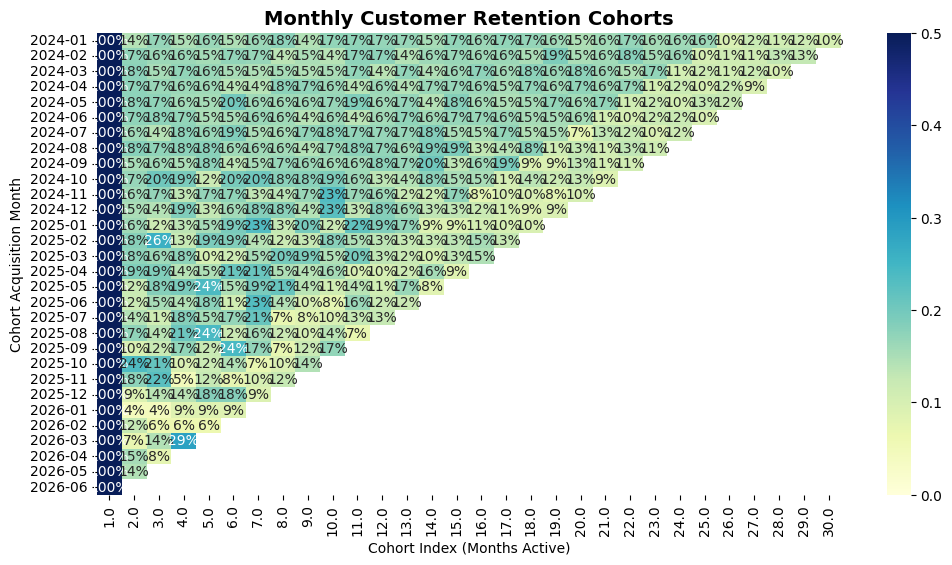

In [3]:
# 1. Build Cohort Counts Matrix
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 2. Convert to Retention Percentages
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Format Cohort Month index for visualization
retention.index = retention.index.strftime('%Y-%m')

# 3. Plot Retention Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=0.5)
plt.title('Monthly Customer Retention Cohorts', fontsize=14, fontweight='bold')
plt.xlabel('Cohort Index (Months Active)')
plt.ylabel('Cohort Acquisition Month')
plt.show()